In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries loaded.")

Libraries loaded.


In [ ]:
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Loaded:", file_name)
print("Shape:", df.shape)
display(df.head())

Saving milan_cortina_2026_cleaned.csv to milan_cortina_2026_cleaned (1).csv
Loaded: milan_cortina_2026_cleaned (1).csv
Shape: (387, 54)


,Athlete_ID,Athlete_Name,Country,Gender,Age,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,Medal,Medal_Clean,Medal_Binary,Gold_Binary,Age_Original,Training_Hours_Per_Week_Original,Body_Fat_Pct_Original,VO2max_Original,Flag_Age_Error,Flag_Training_Error,Flag_BodyFat_Error,Flag_VO2_Error,Missing_Training_Hours_Per_Week,Missing_Altitude_Training_m,Missing_Body_Fat_Pct,Missing_VO2max,Missing_Reaction_Time_ms,Missing_World_Cup_Points_Preseason,MNAR_Reaction_Time_Missing,MNAR_World_Cup_Points_Missing,Outlier_IQR_Age,Outlier_IQR_Previous_Olympics,Outlier_IQR_Training_Hours_Per_Week,Outlier_IQR_Altitude_Training_m,Outlier_IQR_Body_Fat_Pct,Outlier_IQR_VO2max,Outlier_IQR_Reaction_Time_ms,Outlier_IQR_Career_Injuries,Outlier_IQR_World_Cup_Points_Preseason,Outlier_IQR_Country_GDP_per_capita,Outlier_IQR_Winter_Sport_Tradition_Index,VO2_BodyFat_Efficiency,Experience_Training_Index,GDP_Tradition_Index,Training_Injury_Burden,Age_Band,Podium_Group,North_America_Rivalry
0,MC26_1001,Ben Ogden,USA,M,26.0,Cross-Country,1,35.6,1687.0,8.9,91.5,190.0,1,356.0,80000,0.82,Silver,Silver,1,0,26,35.6,NaN,91.5,False,False,False,False,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,10.280899,35.6,65600.0,71.2,23-27,Silver/Bronze,USA
1,MC26_1002,Loic Meillard,SUI,M,30.0,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208.0,1,977.0,93000,0.93,Gold,Gold,1,1,30,22.9,13.9,71.4,False,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.136691,68.7,86490.0,45.8,28-32,Gold,Other
2,MC26_1003,Francesca Lollobrigida,ITA,F,35.0,Speed Skating,1,29.0,394.0,10.1,82.6,189.0,3,416.0,38000,0.82,Gold,Gold,1,1,35,29.0,10.1,82.6,False,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8.178218,29.0,31160.0,116.0,33-37,Gold,Other
3,MC26_1004,Maria Nilsson,FRA,F,43.0,Ski Jumping,4,26.2,1239.0,9.1,59.3,183.0,2,801.0,48000,0.87,NaN,NaN,0,0,43,26.2,9.1,59.3,False,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6.516484,104.8,41760.0,78.6,38+,No Medal,Other
4,MC26_1005,Nils Lewis,GER,M,20.0,Short Track,0,20.2,67.0,12.3,63.1,187.0,2,393.0,52000,0.88,NaN,NaN,0,0,20,20.2,12.3,63.1,False,False,False,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.130081,0.0,45760.0,60.6,Under 23,No Medal,Other


In [ ]:
print("Countries:")
display(df["Country"].value_counts().head(10))

print("\nMedal distribution:")
display(df["Medal_Clean"].value_counts())

print("\nUSA/CAN counts:")
display(df[df["Country"].isin(["USA", "CAN"])]["Country"].value_counts())

print("\nColumns:")
print(df.columns.tolist())

Countries:


,count
Country,
CAN,48
USA,46
SWE,31
GER,24
NOR,24
ITA,23
FRA,18
CHN,18
CZE,17



Medal distribution:


,count
Medal_Clean,
Gold,49
Silver,32
Bronze,23



USA/CAN counts:


,count
Country,
CAN,48
USA,46



Columns:
['Athlete_ID', 'Athlete_Name', 'Country', 'Gender', 'Age', 'Sport', 'Previous_Olympics', 'Training_Hours_Per_Week', 'Altitude_Training_m', 'Body_Fat_Pct', 'VO2max', 'Reaction_Time_ms', 'Career_Injuries', 'World_Cup_Points_Preseason', 'Country_GDP_per_capita', 'Winter_Sport_Tradition_Index', 'Medal', 'Medal_Clean', 'Medal_Binary', 'Gold_Binary', 'Age_Original', 'Training_Hours_Per_Week_Original', 'Body_Fat_Pct_Original', 'VO2max_Original', 'Flag_Age_Error', 'Flag_Training_Error', 'Flag_BodyFat_Error', 'Flag_VO2_Error', 'Missing_Training_Hours_Per_Week', 'Missing_Altitude_Training_m', 'Missing_Body_Fat_Pct', 'Missing_VO2max', 'Missing_Reaction_Time_ms', 'Missing_World_Cup_Points_Preseason', 'MNAR_Reaction_Time_Missing', 'MNAR_World_Cup_Points_Missing', 'Outlier_IQR_Age', 'Outlier_IQR_Previous_Olympics', 'Outlier_IQR_Training_Hours_Per_Week', 'Outlier_IQR_Altitude_Training_m', 'Outlier_IQR_Body_Fat_Pct', 'Outlier_IQR_VO2max', 'Outlier_IQR_Reaction_Time_ms', 'Outlier_IQR_Career_I

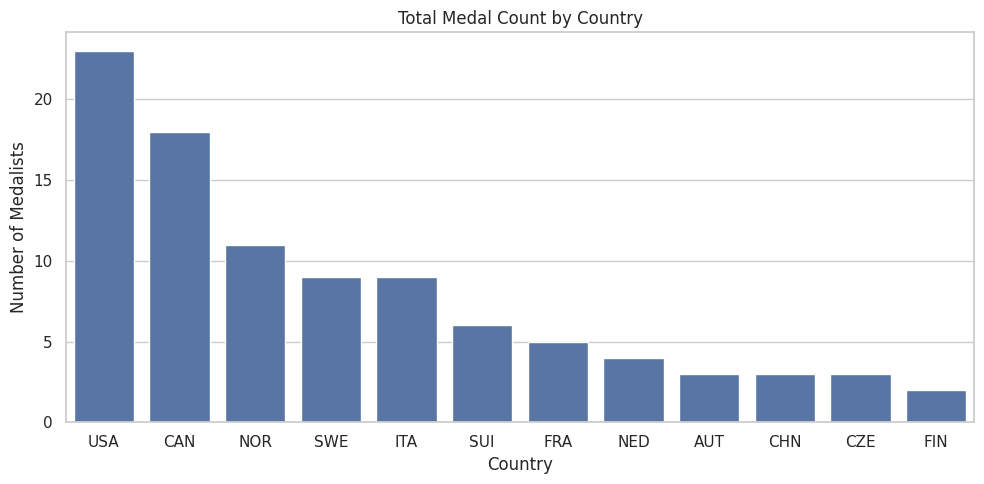

,Country,Total_Medals
16,USA,23
2,CAN,18
13,NOR,11
15,SWE,9
9,ITA,9
14,SUI,6
6,FRA,5
12,NED,4
0,AUT,3
3,CHN,3


In [ ]:
country_medals = (
    df[df["Medal_Binary"] == 1]
    .groupby("Country")
    .size()
    .reset_index(name="Total_Medals")
    .sort_values("Total_Medals", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=country_medals.head(12), x="Country", y="Total_Medals")
plt.title("Total Medal Count by Country")
plt.xlabel("Country")
plt.ylabel("Number of Medalists")
plt.tight_layout()
plt.savefig("figures_country_medal_count.png", dpi=300)
plt.show()

display(country_medals.head(12))

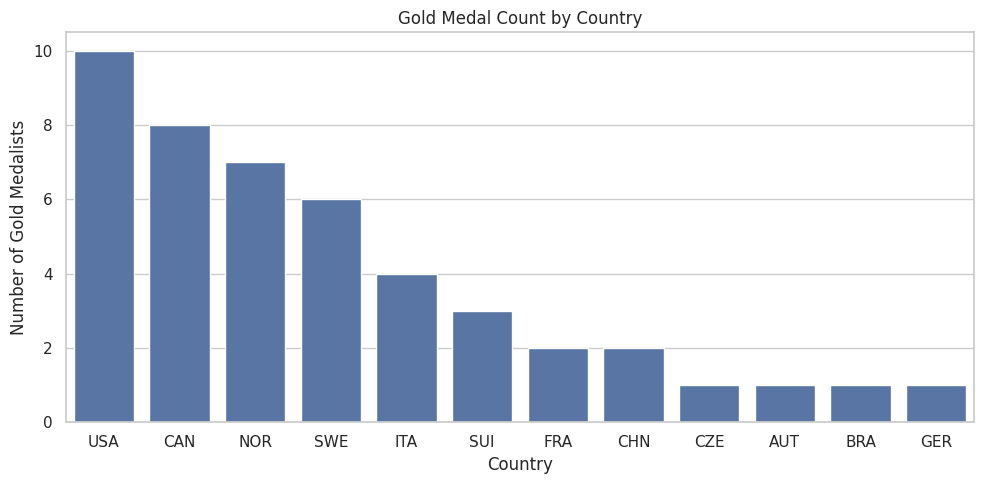

,Country,Gold_Medals
14,USA,10
2,CAN,8
11,NOR,7
13,SWE,6
7,ITA,4
12,SUI,3
5,FRA,2
3,CHN,2
4,CZE,1
0,AUT,1


In [ ]:
country_gold = (
    df[df["Medal_Clean"] == "Gold"]
    .groupby("Country")
    .size()
    .reset_index(name="Gold_Medals")
    .sort_values("Gold_Medals", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=country_gold.head(12), x="Country", y="Gold_Medals")
plt.title("Gold Medal Count by Country")
plt.xlabel("Country")
plt.ylabel("Number of Gold Medalists")
plt.tight_layout()
plt.savefig("figures_country_gold_count.png", dpi=300)
plt.show()

display(country_gold.head(12))

Country,Metric,CAN,USA
0,Training_Hours_Per_Week,24.834375,25.715217
1,VO2max,67.042708,68.021739
2,Altitude_Training_m,1075.583333,1216.434783
3,World_Cup_Points_Preseason,621.010417,600.717391
4,Previous_Olympics,2.375000,2.282609
5,Career_Injuries,3.000000,2.782609
6,Body_Fat_Pct,11.796875,11.734783
7,Reaction_Time_ms,196.979167,195.804348


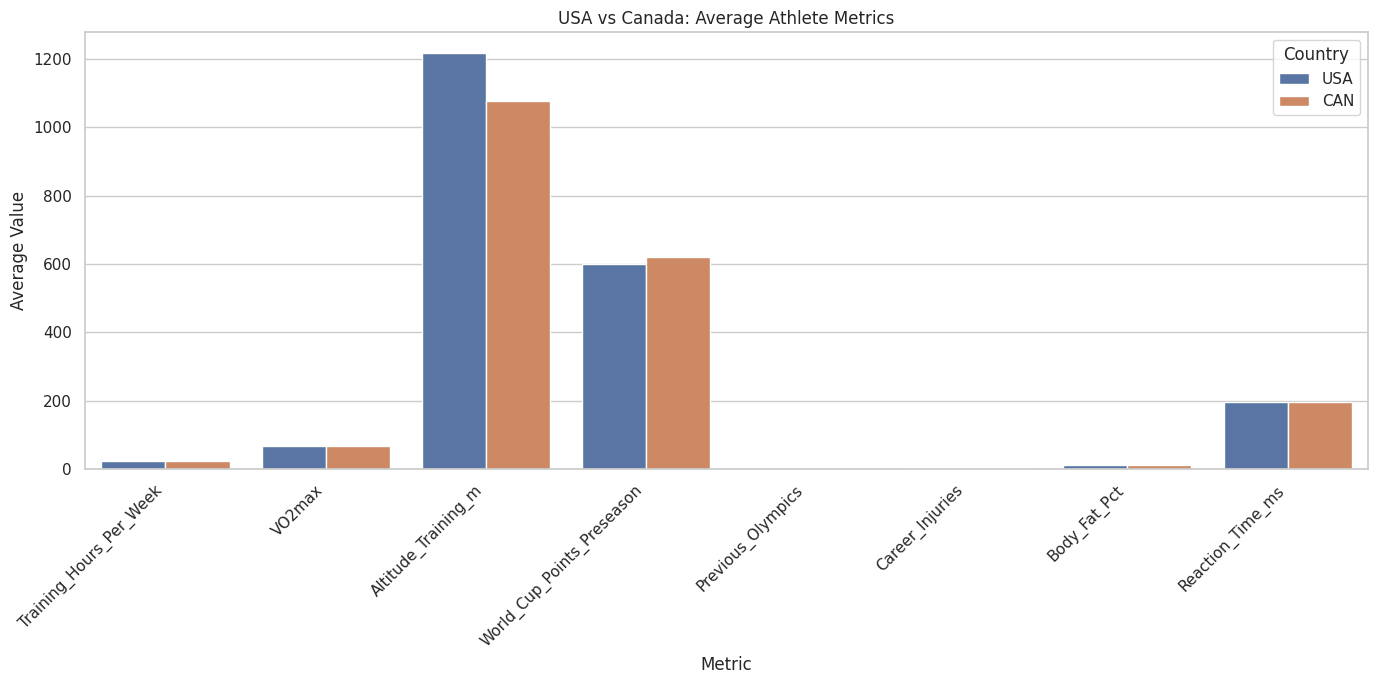

In [ ]:
usa_can = df[df["Country"].isin(["USA", "CAN"])].copy()

metrics = [
    "Training_Hours_Per_Week",
    "VO2max",
    "Altitude_Training_m",
    "World_Cup_Points_Preseason",
    "Previous_Olympics",
    "Career_Injuries",
    "Body_Fat_Pct",
    "Reaction_Time_ms"
]

usa_can_summary = (
    usa_can
    .groupby("Country")[metrics]
    .mean()
    .T
    .reset_index()
    .rename(columns={"index": "Metric"})
)

display(usa_can_summary)

usa_can_long = usa_can.melt(
    id_vars=["Country"],
    value_vars=metrics,
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=usa_can_long, x="Metric", y="Value", hue="Country", errorbar=None)
plt.title("USA vs Canada: Average Athlete Metrics")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures_usa_can_metric_comparison.png", dpi=300)
plt.show()

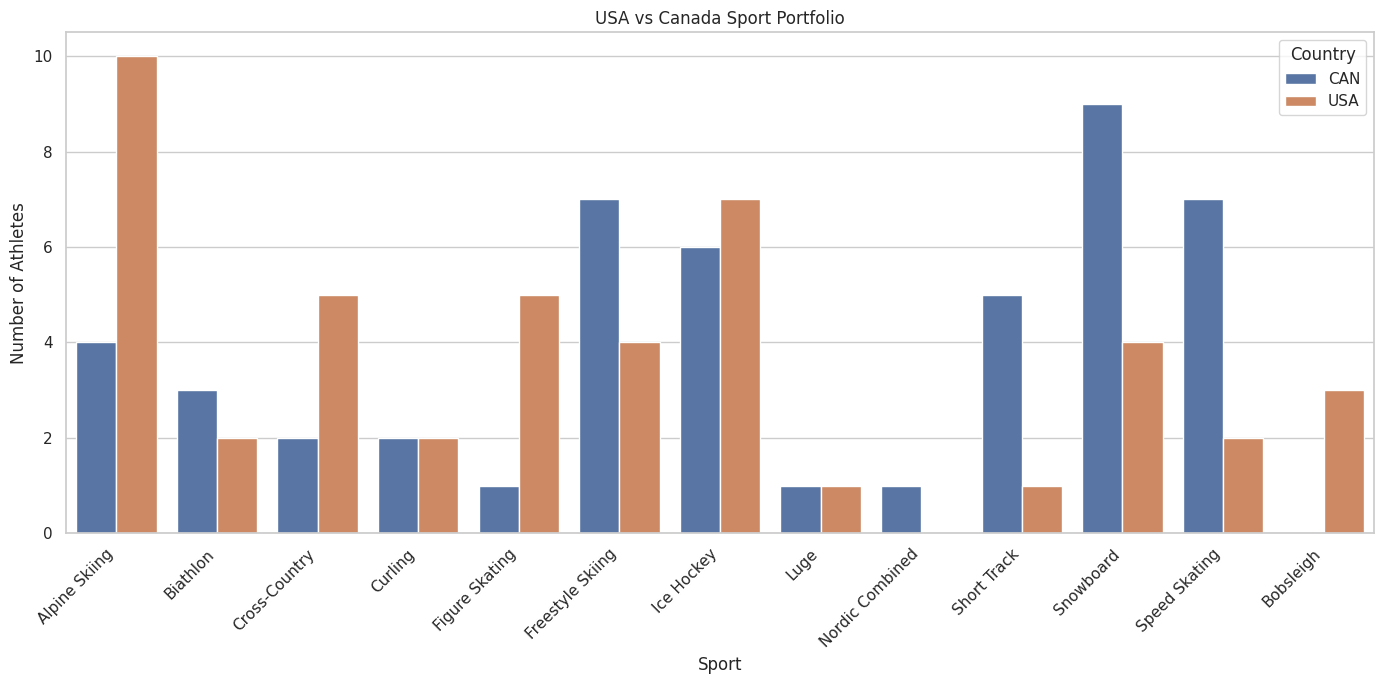

,Country,Sport,Athlete_Count
10,CAN,Snowboard,9
5,CAN,Freestyle Skiing,7
11,CAN,Speed Skating,7
6,CAN,Ice Hockey,6
9,CAN,Short Track,5
0,CAN,Alpine Skiing,4
1,CAN,Biathlon,3
2,CAN,Cross-Country,2
3,CAN,Curling,2
4,CAN,Figure Skating,1


In [ ]:
usa_can_sport = (
    usa_can
    .groupby(["Country", "Sport"])
    .size()
    .reset_index(name="Athlete_Count")
)

plt.figure(figsize=(14, 7))
sns.barplot(data=usa_can_sport, x="Sport", y="Athlete_Count", hue="Country")
plt.title("USA vs Canada Sport Portfolio")
plt.xlabel("Sport")
plt.ylabel("Number of Athletes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures_usa_can_sport_portfolio.png", dpi=300)
plt.show()

display(usa_can_sport.sort_values(["Country", "Athlete_Count"], ascending=[True, False]))

,Country,Sport,Athletes,Medalists,Golds,Medal_Rate,Gold_Rate
3,CAN,Curling,2,2,2,1.000000,1.000000
6,CAN,Ice Hockey,6,4,0,0.666667,0.000000
9,CAN,Short Track,5,3,1,0.600000,0.200000
5,CAN,Freestyle Skiing,7,4,2,0.571429,0.285714
11,CAN,Speed Skating,7,4,3,0.571429,0.428571
10,CAN,Snowboard,9,1,0,0.111111,0.000000
0,CAN,Alpine Skiing,4,0,0,0.000000,0.000000
1,CAN,Biathlon,3,0,0,0.000000,0.000000
2,CAN,Cross-Country,2,0,0,0.000000,0.000000
4,CAN,Figure Skating,1,0,0,0.000000,0.000000


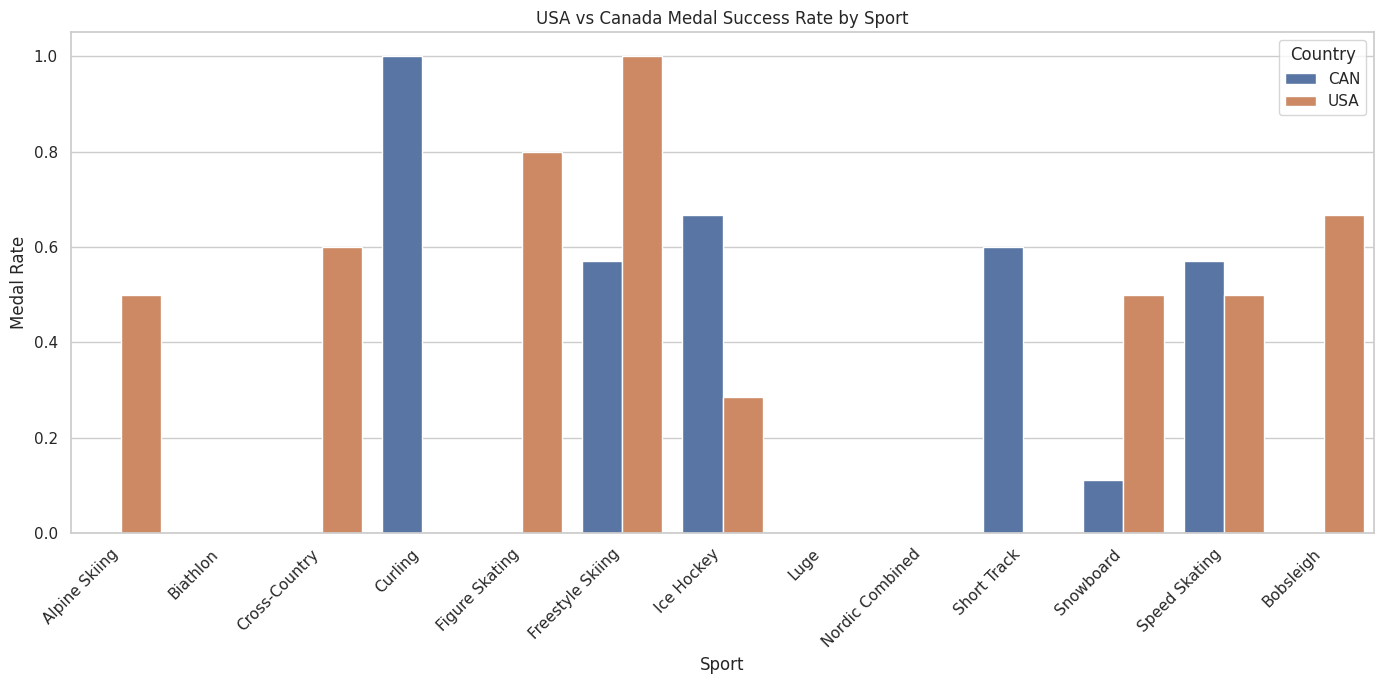

In [ ]:
usa_can_sport_success = (
    usa_can
    .groupby(["Country", "Sport"])
    .agg(
        Athletes=("Athlete_ID", "count"),
        Medalists=("Medal_Binary", "sum"),
        Golds=("Gold_Binary", "sum")
    )
    .reset_index()
)

usa_can_sport_success["Medal_Rate"] = usa_can_sport_success["Medalists"] / usa_can_sport_success["Athletes"]
usa_can_sport_success["Gold_Rate"] = usa_can_sport_success["Golds"] / usa_can_sport_success["Athletes"]

display(usa_can_sport_success.sort_values(["Country", "Medal_Rate"], ascending=[True, False]))

plt.figure(figsize=(14, 7))
sns.barplot(data=usa_can_sport_success, x="Sport", y="Medal_Rate", hue="Country")
plt.title("USA vs Canada Medal Success Rate by Sport")
plt.xlabel("Sport")
plt.ylabel("Medal Rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures_usa_can_sport_medal_rate.png", dpi=300)
plt.show()

,Age,Previous_Olympics,Training_Hours_Per_Week,VO2max,Body_Fat_Pct,World_Cup_Points_Preseason,Career_Injuries
Podium_Group,,,,,,,
Gold,29.12,2.84,28.67,76.61,11.73,677.94,2.10
No Medal,31.36,2.09,24.74,66.48,11.91,571.67,2.67
Silver/Bronze,32.20,2.55,27.54,73.92,11.60,617.72,2.33


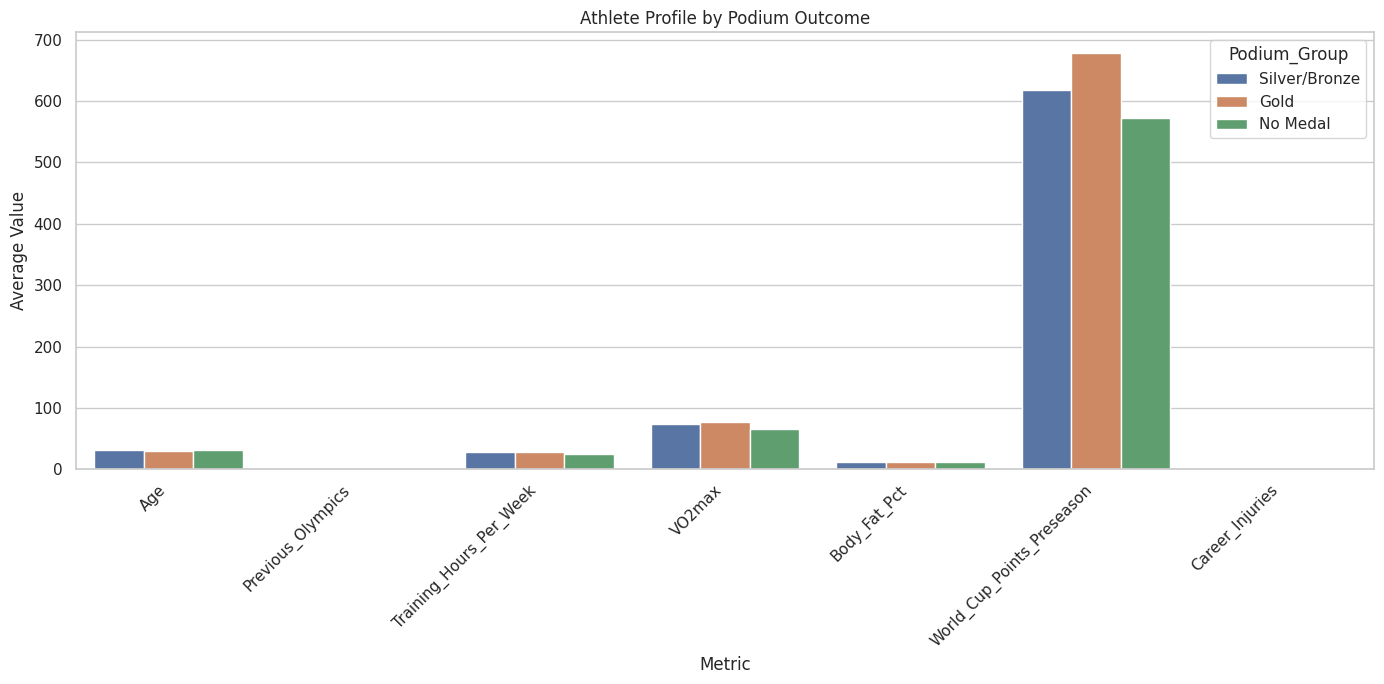

In [ ]:
profile_metrics = [
    "Age",
    "Previous_Olympics",
    "Training_Hours_Per_Week",
    "VO2max",
    "Body_Fat_Pct",
    "World_Cup_Points_Preseason",
    "Career_Injuries"
]

podium_summary = (
    df.groupby("Podium_Group")[profile_metrics]
    .mean()
    .round(2)
)

display(podium_summary)

podium_long = df.melt(
    id_vars=["Podium_Group"],
    value_vars=profile_metrics,
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=podium_long, x="Metric", y="Value", hue="Podium_Group", errorbar=None)
plt.title("Athlete Profile by Podium Outcome")
plt.xlabel("Metric")
plt.ylabel("Average Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures_podium_group_profile.png", dpi=300)
plt.show()

,Age_Band,Athletes,Medalists,Golds,Medal_Rate,Gold_Rate
0,23-27,82,27,14,0.329268,0.170732
1,28-32,87,29,14,0.333333,0.160920
2,33-37,85,28,10,0.329412,0.117647
3,38+,82,11,3,0.134146,0.036585
4,Under 23,51,9,8,0.176471,0.156863


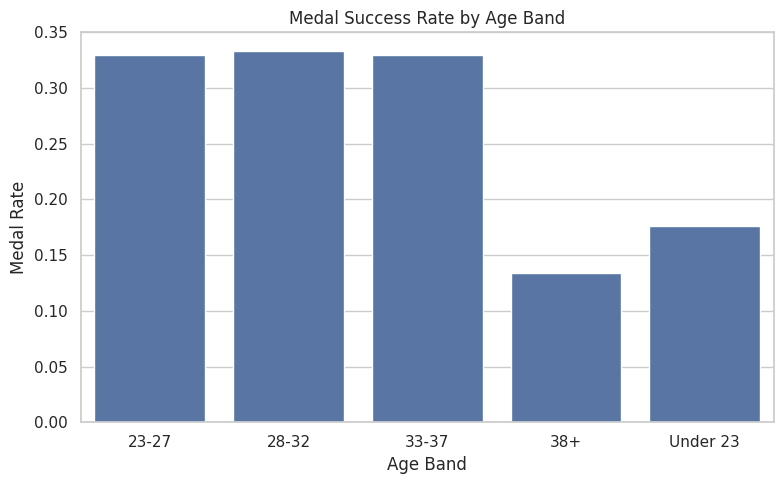

In [ ]:
age_success = (
    df.groupby("Age_Band")
    .agg(
        Athletes=("Athlete_ID", "count"),
        Medalists=("Medal_Binary", "sum"),
        Golds=("Gold_Binary", "sum")
    )
    .reset_index()
)

age_success["Medal_Rate"] = age_success["Medalists"] / age_success["Athletes"]
age_success["Gold_Rate"] = age_success["Golds"] / age_success["Athletes"]

display(age_success)

plt.figure(figsize=(8, 5))
sns.barplot(data=age_success, x="Age_Band", y="Medal_Rate")
plt.title("Medal Success Rate by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Medal Rate")
plt.tight_layout()
plt.savefig("figures_medal_rate_by_age_band.png", dpi=300)
plt.show()

,Previous_Olympics,Athletes,Medalists,Golds,Medal_Rate,Gold_Rate
0,0,44,0,0,0.000000,0.000000
1,1,95,29,14,0.305263,0.147368
2,2,76,19,6,0.250000,0.078947
3,3,92,23,13,0.250000,0.141304
4,4,52,22,6,0.423077,0.115385
5,5,28,11,10,0.392857,0.357143


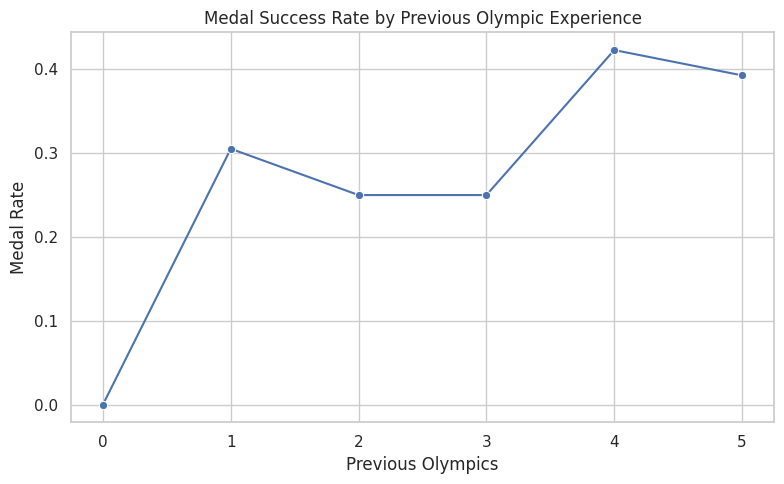

In [ ]:
experience_success = (
    df.groupby("Previous_Olympics")
    .agg(
        Athletes=("Athlete_ID", "count"),
        Medalists=("Medal_Binary", "sum"),
        Golds=("Gold_Binary", "sum")
    )
    .reset_index()
)

experience_success["Medal_Rate"] = experience_success["Medalists"] / experience_success["Athletes"]
experience_success["Gold_Rate"] = experience_success["Golds"] / experience_success["Athletes"]

display(experience_success)

plt.figure(figsize=(8, 5))
sns.lineplot(data=experience_success, x="Previous_Olympics", y="Medal_Rate", marker="o")
plt.title("Medal Success Rate by Previous Olympic Experience")
plt.xlabel("Previous Olympics")
plt.ylabel("Medal Rate")
plt.tight_layout()
plt.savefig("figures_medal_rate_by_experience.png", dpi=300)
plt.show()

,Country,Athletes,Medalists,Golds,GDP,Tradition,Medal_Rate,Gold_Rate
22,USA,46,23,10,80000.0,0.82,0.500000,0.217391
15,NOR,24,11,7,95000.0,0.97,0.458333,0.291667
11,ITA,23,9,4,38000.0,0.82,0.391304,0.173913
3,CAN,48,18,8,55000.0,0.88,0.375000,0.166667
19,SUI,17,6,3,93000.0,0.93,0.352941,0.176471
21,SWE,31,9,6,56000.0,0.91,0.290323,0.193548
7,FRA,18,5,2,48000.0,0.87,0.277778,0.111111
14,NED,16,4,1,62000.0,0.85,0.250000,0.062500
1,AUT,12,3,1,56000.0,0.92,0.250000,0.083333
6,FIN,11,2,0,53000.0,0.90,0.181818,0.000000


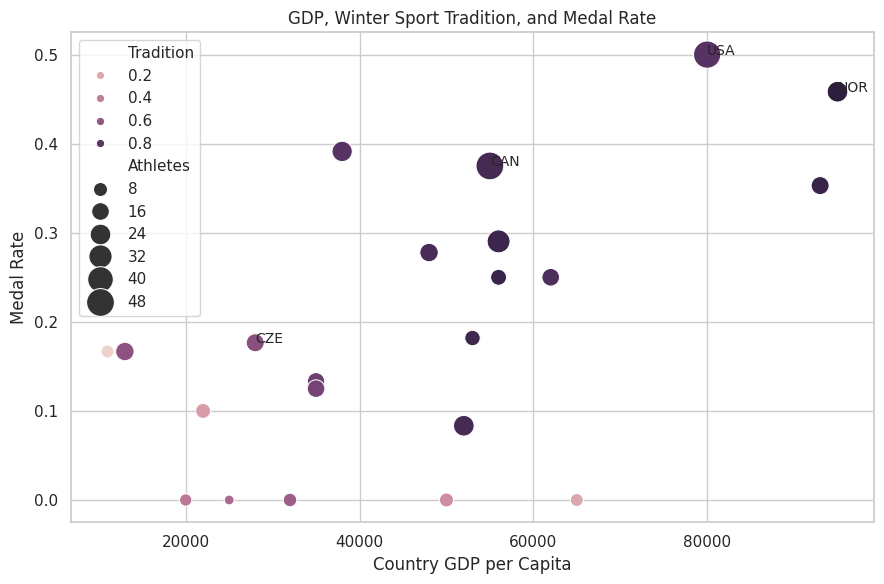

In [ ]:
country_context = (
    df.groupby("Country")
    .agg(
        Athletes=("Athlete_ID", "count"),
        Medalists=("Medal_Binary", "sum"),
        Golds=("Gold_Binary", "sum"),
        GDP=("Country_GDP_per_capita", "mean"),
        Tradition=("Winter_Sport_Tradition_Index", "mean")
    )
    .reset_index()
)

country_context["Medal_Rate"] = country_context["Medalists"] / country_context["Athletes"]
country_context["Gold_Rate"] = country_context["Golds"] / country_context["Athletes"]

display(country_context.sort_values("Medal_Rate", ascending=False))

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=country_context,
    x="GDP",
    y="Medal_Rate",
    size="Athletes",
    hue="Tradition",
    sizes=(50, 400)
)

for _, row in country_context.iterrows():
    if row["Country"] in ["USA", "CAN", "NOR", "CZE"]:
        plt.text(row["GDP"], row["Medal_Rate"], row["Country"], fontsize=10)

plt.title("GDP, Winter Sport Tradition, and Medal Rate")
plt.xlabel("Country GDP per Capita")
plt.ylabel("Medal Rate")
plt.tight_layout()
plt.savefig("figures_gdp_tradition_medal_rate.png", dpi=300)
plt.show()

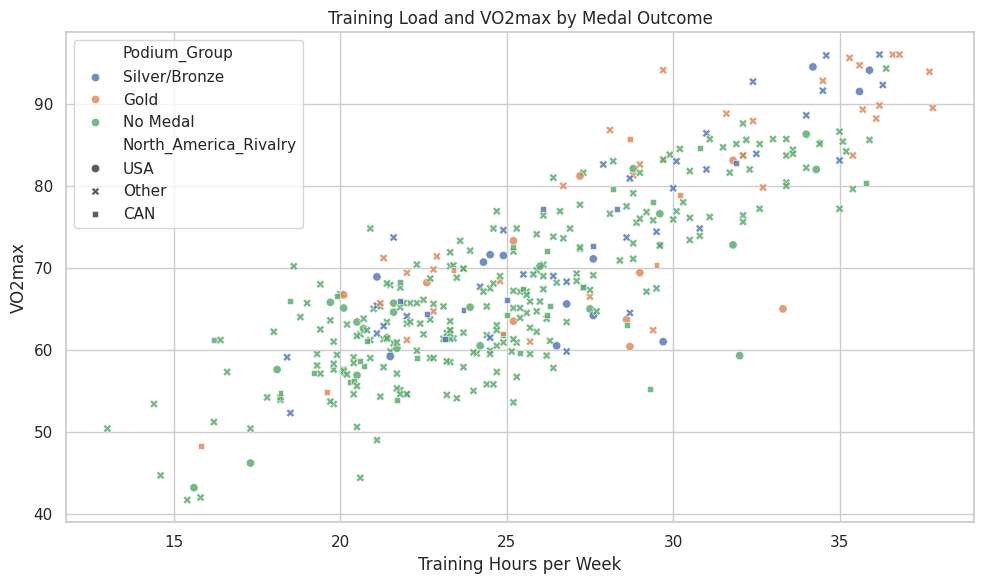

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Training_Hours_Per_Week",
    y="VO2max",
    hue="Podium_Group",
    style="North_America_Rivalry",
    alpha=0.8
)

plt.title("Training Load and VO2max by Medal Outcome")
plt.xlabel("Training Hours per Week")
plt.ylabel("VO2max")
plt.tight_layout()
plt.savefig("figures_training_vo2_medal_outcome.png", dpi=300)
plt.show()

,Sport,Medal_Binary,Mean_VO2,Median_VO2,Athletes,Medal_Status
0,Alpine Skiing,0,63.819048,64.800,42,No Medal
1,Alpine Skiing,1,70.976471,70.700,17,Medalist
2,Biathlon,0,80.046429,81.300,28,No Medal
3,Biathlon,1,86.818182,83.700,11,Medalist
4,Bobsleigh,0,62.880000,62.700,10,No Medal
5,Bobsleigh,1,70.750000,70.350,4,Medalist
6,Cross-Country,0,82.503571,83.550,28,No Medal
7,Cross-Country,1,93.133333,93.900,15,Medalist
8,Curling,0,47.409091,46.200,11,No Medal
9,Curling,1,53.650000,53.600,4,Medalist


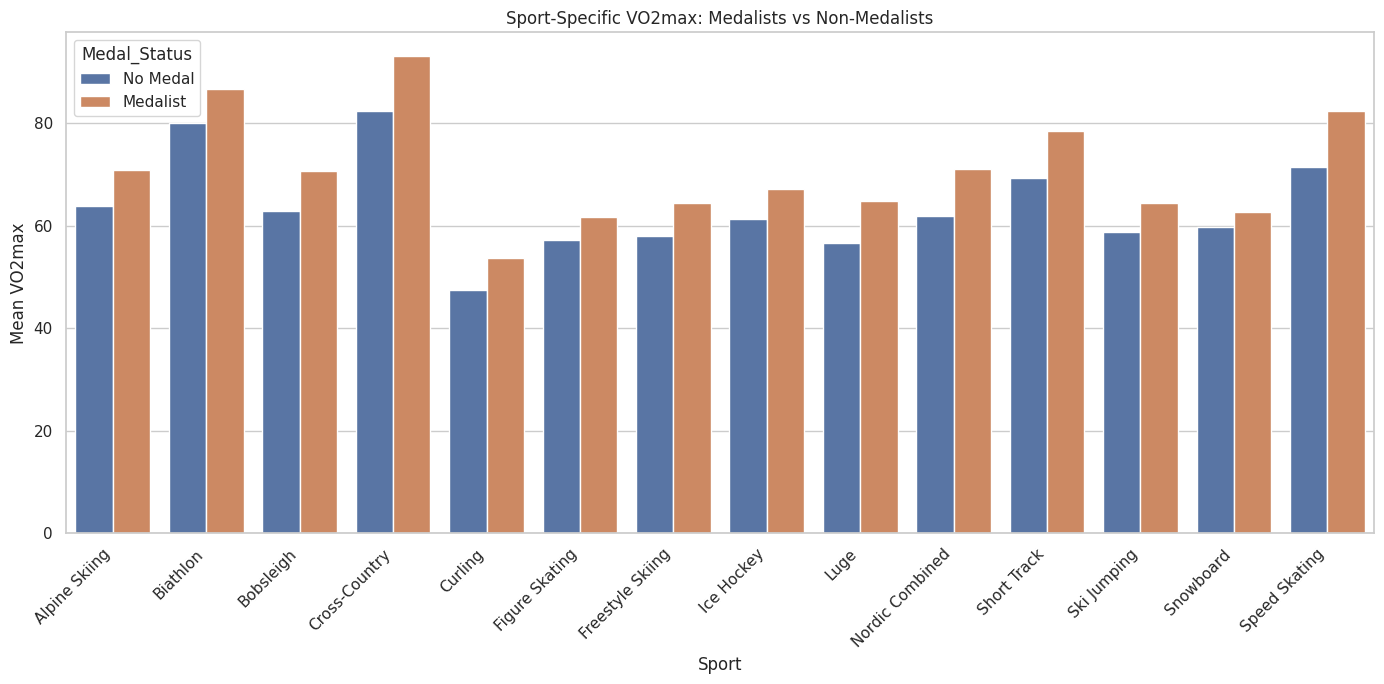

In [ ]:
sport_vo2 = (
    df.groupby(["Sport", "Medal_Binary"])
    .agg(
        Mean_VO2=("VO2max", "mean"),
        Median_VO2=("VO2max", "median"),
        Athletes=("Athlete_ID", "count")
    )
    .reset_index()
)

sport_vo2["Medal_Status"] = sport_vo2["Medal_Binary"].map({0: "No Medal", 1: "Medalist"})

display(sport_vo2)

plt.figure(figsize=(14, 7))
sns.barplot(data=sport_vo2, x="Sport", y="Mean_VO2", hue="Medal_Status")
plt.title("Sport-Specific VO2max: Medalists vs Non-Medalists")
plt.xlabel("Sport")
plt.ylabel("Mean VO2max")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures_sport_specific_vo2_medalists.png", dpi=300)
plt.show()

In [ ]:
usa_can_summary.to_csv("eda_usa_can_metric_summary.csv", index=False)
usa_can_sport_success.to_csv("eda_usa_can_sport_success.csv", index=False)
podium_summary.to_csv("eda_podium_profile_summary.csv")
age_success.to_csv("eda_age_success_summary.csv", index=False)
experience_success.to_csv("eda_experience_success_summary.csv", index=False)
country_context.to_csv("eda_country_context_summary.csv", index=False)
sport_vo2.to_csv("eda_sport_vo2_summary.csv", index=False)

print("EDA tables exported.")

EDA tables exported.
